# ECG 多标签分类 — 模型训练
本 notebook 与 `src/train.py` 逻辑完全一致，按 cell 顺序运行即可训练模型。

## 说明
- **数据**：官方划分 `data/processed/{train,val,test}`，10 类多标签（已按 value>0 修复标签编码）
- **验证集**：使用官方 `data/processed/val`（与 `evaluate.py` 阈值搜索一致）
- **路径**：所有路径相对项目根目录（ECG_Model/）自动定位
- **输出**：`models/checkpoints/best_model.pth`（val loss 最优权重）+ TensorBoard 日志
- **运行**：`Jupyter → Run All`（CPU 上 50 epochs 需要数小时，请耐心等待）


## 1. 环境与路径设置

In [1]:
import os
import sys
import json
import yaml
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from datetime import datetime

try:
    from torch.utils.tensorboard import SummaryWriter
    HAS_TB = True
except ImportError:
    HAS_TB = False
    print("提示：未安装 tensorboard，将跳过 TensorBoard 日志（pip install tensorboard 可启用）")

# 项目根目录自动定位（notebook 在 src/ 下）
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if not os.path.exists(os.path.join(PROJECT_ROOT, "configs", "config.yaml")):
    PROJECT_ROOT = os.getcwd()
sys.path.insert(0, PROJECT_ROOT)

from models.model_zoo.resnet1d import resnet18_1d, resnet34_1d


def _resolve(path):
    """相对路径基于项目根解析；绝对路径原样返回"""
    if os.path.isabs(path):
        return path
    return os.path.join(PROJECT_ROOT, path)

print("项目根目录:", PROJECT_ROOT)

项目根目录: d:\Code.VSC\ECG_Model


## 2. 损失函数：Focal Loss
- `gamma`：聚焦参数，抑制易分样本梯度
- `alpha`：类别权重（可传 list，长度=类别数），缓解类别不平衡

In [2]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, inputs, targets):
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = (1 - pt) ** self.gamma * BCE_loss

        if self.alpha is not None:
            if isinstance(self.alpha, list):
                alpha_t = torch.tensor(self.alpha, dtype=inputs.dtype, device=inputs.device)
            elif isinstance(self.alpha, (float, int)):
                num_classes = inputs.size(1)
                alpha_t = torch.full((num_classes,), self.alpha, dtype=inputs.dtype, device=inputs.device)
            else:
                alpha_t = self.alpha
            alpha_weight = alpha_t * targets + (1 - alpha_t) * (1 - targets)
            F_loss = alpha_weight * F_loss

        if self.reduction == 'mean':
            return F_loss.mean()
        elif self.reduction == 'sum':
            return F_loss.sum()
        else:
            return F_loss

## 3. 数据加载（官方 train / val / test 划分）

In [3]:
def load_data(data_dir):
    """加载官方 train / val / test 划分"""
    def load_npy(rel):
        return np.load(os.path.join(data_dir, rel)).astype(np.float32)

    train_signals = load_npy(os.path.join('train', 'signals.npy'))
    train_labels = load_npy(os.path.join('labels', 'train_multilabel.npy'))
    val_signals = load_npy(os.path.join('val', 'signals.npy'))
    val_labels = load_npy(os.path.join('labels', 'val_multilabel.npy'))
    test_signals = load_npy(os.path.join('test', 'signals.npy'))
    test_labels = load_npy(os.path.join('labels', 'test_multilabel.npy'))
    return (train_signals, train_labels, val_signals, val_labels, test_signals, test_labels)


def get_pos_weights(labels, override=None):
    """每个类别的正样本权重（负例数/正例数）"""
    if override is not None and len(override) > 0:
        print(f"使用手动设置的正样本权重: {override}")
        return torch.tensor(override, dtype=torch.float32)
    num_pos = labels.sum(axis=0)
    num_neg = len(labels) - num_pos
    pos_weight = num_neg / (num_pos + 1e-6)
    print(f"自动计算正样本权重: {pos_weight}")
    return torch.tensor(pos_weight, dtype=torch.float32)


def get_weighted_sampler(labels):
    """加权采样器：稀有类别样本更可能被采样"""
    pos_counts = labels.sum(axis=0) + 1e-6
    class_weights = 1.0 / pos_counts
    sample_weights = (labels * class_weights).sum(axis=1)
    sample_weights /= sample_weights.sum()
    return WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

## 4. 训练 / 验证函数

In [4]:
def train_epoch(model, dataloader, criterion, optimizer, device, label_smoothing=0.0):
    model.train()
    running_loss = 0.0
    for signals, labels in dataloader:
        signals, labels = signals.to(device), labels.to(device)
        if label_smoothing > 0:
            labels = labels * (1 - label_smoothing) + 0.5 * label_smoothing
        optimizer.zero_grad()
        logits = model(signals)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item() * signals.size(0)
    return running_loss / len(dataloader.dataset)


def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for signals, labels in dataloader:
            signals, labels = signals.to(device), labels.to(device)
            logits = model(signals)
            loss = criterion(logits, labels)
            running_loss += loss.item() * signals.size(0)
    return running_loss / len(dataloader.dataset)

## 5. 读取配置并准备数据 / 模型

In [5]:
# ===== 配置 =====
config_path = _resolve('configs/config.yaml')
with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

train_cfg = config['training']
model_cfg = config['model']
num_classes = config['data']['num_classes']
class_names = config['data']['class_names']
print("类别:", class_names)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("使用设备:", device)

# ===== 数据 =====
data_dir = _resolve(config['data']['processed_dir'])
X_train, y_train, X_val, y_val, X_test, y_test = load_data(data_dir)
print(f"训练集: {X_train.shape}  验证集: {X_val.shape}  测试集: {X_test.shape}")

# ===== DataLoader =====
use_weighted_sampler = train_cfg.get('use_weighted_sampler', False)
if use_weighted_sampler:
    print("启用 WeightedRandomSampler 以缓解类别不平衡")
    sampler = get_weighted_sampler(y_train)
    train_loader = DataLoader(TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
                              batch_size=train_cfg['batch_size'], sampler=sampler)
else:
    train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
    train_loader = DataLoader(train_dataset, batch_size=train_cfg['batch_size'], shuffle=True)

val_dataset = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
val_loader = DataLoader(val_dataset, batch_size=train_cfg['batch_size'], shuffle=False)

# ===== 模型 =====
model_name = model_cfg.get('name', 'resnet18')
dropout = model_cfg.get('dropout', 0.3)
if model_name == 'resnet34':
    model = resnet34_1d(in_channels=12, num_classes=num_classes, dropout=dropout)
else:
    model = resnet18_1d(in_channels=12, num_classes=num_classes, dropout=dropout)
model = model.to(device)
print(f"模型: {model_name} | 参数量: {sum(p.numel() for p in model.parameters()):,}")

类别: ['NORM', 'IMI', 'ASMI', 'LVH', 'NDT', 'LAFB', 'ISC_', 'IRBBB', 'PVC', 'IVCD']
使用设备: cpu
训练集: (17181, 12, 1000)  验证集: (2136, 12, 1000)  测试集: (2161, 12, 1000)
启用 WeightedRandomSampler 以缓解类别不平衡
模型: resnet18 | 参数量: 3,941,002


## 6. 损失函数、优化器、调度器

In [6]:
label_smoothing = float(train_cfg.get('label_smoothing', 0.0))
if label_smoothing > 0:
    print(f"启用标签平滑，平滑系数: {label_smoothing}")

loss_type = train_cfg.get('loss_type', 'bce').lower()
if loss_type == 'focal':
    alpha = train_cfg.get('focal_alpha', 0.25)
    gamma = train_cfg.get('focal_gamma', 2.0)
    print(f"使用 Focal Loss (alpha={alpha}, gamma={gamma})")
    criterion = FocalLoss(alpha=alpha, gamma=gamma)
else:
    pos_weight_override = train_cfg.get('pos_weight_override', None)
    pos_weight = get_pos_weights(y_train, override=pos_weight_override)
    if train_cfg.get('use_weighted_bce', True):
        print("使用加权 BCEWithLogitsLoss")
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
    else:
        print("使用不加权 BCEWithLogitsLoss")
        criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=float(train_cfg['learning_rate']),
    weight_decay=float(train_cfg.get('weight_decay', 5e-4))
)

scheduler_patience = train_cfg.get('lr_scheduler_patience', 10)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=scheduler_patience
)

# 日志与保存路径
log_root = _resolve(config['paths'].get('log_dir', 'logs'))
os.makedirs(log_root, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
log_dir = os.path.join(log_root, f'{model_name}_{timestamp}')
writer = SummaryWriter(log_dir) if HAS_TB else None
checkpoint_dir = _resolve(config['paths']['checkpoints'])
os.makedirs(checkpoint_dir, exist_ok=True)
print("日志目录:", log_dir)

使用 Focal Loss (alpha=[0.1, 0.15, 0.7, 0.75, 0.75, 0.8, 0.85, 0.7, 0.2, 0.75], gamma=3.0)
日志目录: d:\Code.VSC\ECG_Model\logs\resnet18_20260822_224510


## 7. 训练循环（含早停）
> CPU 训练较慢，可修改 `configs/config.yaml` 中的 `epochs` 减少轮数快速验证。

In [7]:
best_val_loss = float('inf')
patience_counter = 0
patience = train_cfg['early_stopping_patience']
epochs = train_cfg['epochs']

history = {'train_loss': [], 'val_loss': [], 'lr': []}
print(f"\n开始训练，共 {epochs} 轮，早停耐心值 {patience}")
for epoch in range(1, epochs + 1):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device,
                             label_smoothing=label_smoothing)
    val_loss = validate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    if writer is not None:
        writer.add_scalar('Loss/train', train_loss, epoch)
        writer.add_scalar('Loss/val', val_loss, epoch)
        writer.add_scalar('LR', optimizer.param_groups[0]['lr'], epoch)

    print(f"Epoch {epoch:3d}/{epochs} | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(checkpoint_dir, 'best_model.pth'))
        print(f"  ✓ 保存最佳模型 (Val Loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"早停触发，在第 {epoch} 轮停止训练")
            break

if writer is not None:
    writer.close()
print(f"\n训练完成，最佳验证损失: {best_val_loss:.4f}")
print(f"模型保存至: {os.path.join(checkpoint_dir, 'best_model.pth')}")

train_info = {
    'config': config_path,
    'model_name': model_name,
    'best_val_loss': best_val_loss,
    'checkpoint': os.path.join(checkpoint_dir, 'best_model.pth'),
    'log_dir': log_dir,
    'class_names': class_names,
    'epochs_done': len(history['train_loss']),
}
with open(os.path.join(log_dir, 'train_info.json'), 'w') as f:
    json.dump(train_info, f, indent=2)
print("训练信息已保存至:", os.path.join(log_dir, 'train_info.json'))


开始训练，共 50 轮，早停耐心值 10
Epoch   1/50 | Train Loss: 0.0180 | Val Loss: 0.0153 | LR: 5.00e-04
  ✓ 保存最佳模型 (Val Loss: 0.0153)
Epoch   2/50 | Train Loss: 0.0148 | Val Loss: 0.0130 | LR: 5.00e-04
  ✓ 保存最佳模型 (Val Loss: 0.0130)
Epoch   3/50 | Train Loss: 0.0140 | Val Loss: 0.0125 | LR: 5.00e-04
  ✓ 保存最佳模型 (Val Loss: 0.0125)
Epoch   4/50 | Train Loss: 0.0140 | Val Loss: 0.0117 | LR: 5.00e-04
  ✓ 保存最佳模型 (Val Loss: 0.0117)
Epoch   5/50 | Train Loss: 0.0137 | Val Loss: 0.0137 | LR: 5.00e-04
Epoch   6/50 | Train Loss: 0.0135 | Val Loss: 0.0133 | LR: 5.00e-04
Epoch   7/50 | Train Loss: 0.0133 | Val Loss: 0.0135 | LR: 5.00e-04
Epoch   8/50 | Train Loss: 0.0136 | Val Loss: 0.0129 | LR: 5.00e-04
Epoch   9/50 | Train Loss: 0.0136 | Val Loss: 0.0134 | LR: 5.00e-04
Epoch  10/50 | Train Loss: 0.0135 | Val Loss: 0.0127 | LR: 5.00e-04
Epoch  11/50 | Train Loss: 0.0136 | Val Loss: 0.0121 | LR: 5.00e-04
Epoch  12/50 | Train Loss: 0.0136 | Val Loss: 0.0117 | LR: 5.00e-04
  ✓ 保存最佳模型 (Val Loss: 0.0117)
Epoch  13/50

## 8. 训练曲线可视化

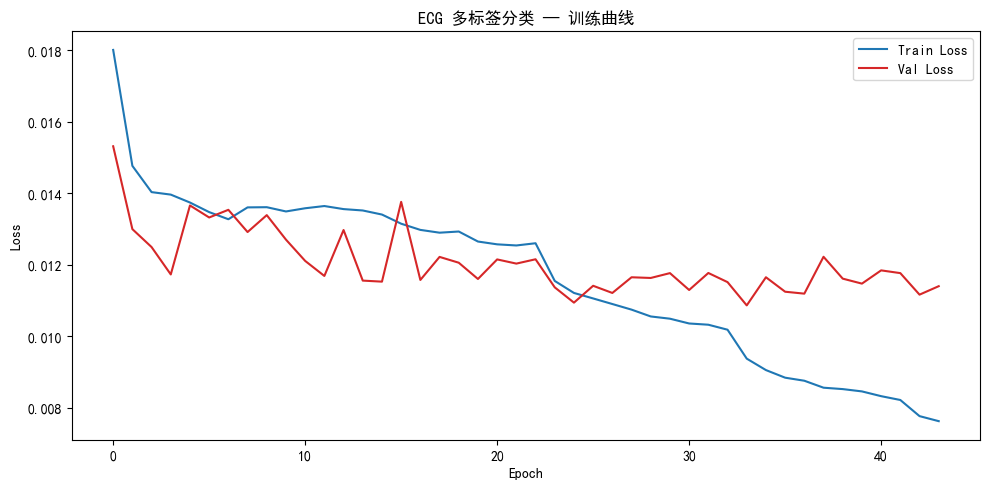

训练曲线已保存至 reports/training_curve.png


In [8]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(history['train_loss'], label='Train Loss', color='tab:blue')
ax1.plot(history['val_loss'], label='Val Loss', color='tab:red')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.set_title('ECG 多标签分类 — 训练曲线')
plt.tight_layout()
plt.show()

# 保存曲线图
os.makedirs(_resolve('reports'), exist_ok=True)
fig.savefig(_resolve(os.path.join('reports', 'training_curve.png')), dpi=150)
print("训练曲线已保存至 reports/training_curve.png")